# Week 10 Instructor-led Lab: Data Reduction

Author: Hali Evans    
Course: BGEN632    
Purpose: Practice implementing data reduction techniques in Python.

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# for pca
from sklearn import preprocessing
from sklearn.decomposition import PCA as pca

# for factor analysis
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_bartlett_sphericity
from factor_analyzer.factor_analyzer import calculate_kmo

# for k-means clustering 
import sklearn.metrics as metcs
from scipy.cluster import hierarchy as hier
from sklearn import cluster as cls

# for decision tree 
from sklearn.feature_extraction.image import grid_to_graph
from sklearn import tree

# modules for plotting trees
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import display

In [5]:
# set working directory
os.chdir("/Users/halievans/Documents/BGEN632/week10labs/data")  # add your filepath within the quotes
os.getcwd()  # confirm change

'/Users/halievans/Documents/BGEN632/week10labs/data'

In [6]:
# load data
hospital_df = pd.read_csv("calihospital.txt", sep="\t")
hospital_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HospitalID     61 non-null     int64  
 1   Name           61 non-null     object 
 2   Zip            61 non-null     object 
 3   Website        61 non-null     object 
 4   TypeControl    61 non-null     object 
 5   Teaching       61 non-null     object 
 6   DonorType      61 non-null     object 
 7   NoFTE          61 non-null     float64
 8   NetPatRev      61 non-null     float64
 9   InOperExp      61 non-null     float64
 10  OutOperExp     61 non-null     float64
 11  OperRev        61 non-null     int64  
 12  OperInc        61 non-null     int64  
 13  AvlBeds        61 non-null     int64  
 14  Work_ID        61 non-null     int64  
 15  LastName       61 non-null     object 
 16  FirstName      61 non-null     object 
 17  Gender         61 non-null     object 
 18  PositionID  

## Principal Component Analysis (PCA) Python

In [8]:
# select columns
hospital_df_pca = hospital_df[[
    'NoFTE', 
    'NetPatRev', 
    'InOperExp', 
    'OutOperExp', 
    'OperRev', 
    'OperInc', 
    'AvlBeds']]

# run the PCA - we specify 7 components because we have 7 variables in the DataFrame
pca_result = pca(n_components=7).fit(hospital_df_pca)

# obtain eigenvalues
pca_result.explained_variance_

array([2.75753261e+17, 6.75028311e+15, 2.04591348e+15, 2.44102791e+09,
       3.37008097e+05, 6.33647054e+03, 4.13822591e-05])

#### Based on the eigenvalues 6/7 of the variable should be kept.
2.75753261e+17 Keep >= 1.0    
6.75028311e+15 Keep >= 1.0    
2.04591348e+15 Keep >= 1.0    
2.44102791e+09 Keep >= 1.0    
3.37008097e+05 Keep >= 1.0    
6.33647054e+03 Keep >= 1.0    
4.13822591e-05 Remove < 1.0

In [10]:
# obtain percentage of variance explained by the principal component
pca_result.explained_variance_ratio_

array([9.69087276e-01, 2.37227057e-02, 7.19001006e-03, 8.57857158e-09,
       1.18435683e-12, 2.22684328e-14, 1.45430812e-22])

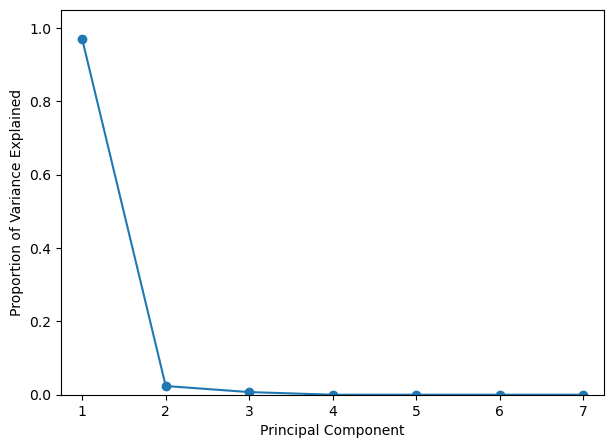

In [11]:
# generate scree plot
plt.figure(figsize=(7,5))
plt.plot([1,2,3,4,5,6,7], pca_result.explained_variance_ratio_, '-o')
plt.ylabel('Proportion of Variance Explained')
plt.xlabel('Principal Component')
plt.xlim(0.75, 7.25)
plt.ylim(0, 1.05)
plt.xticks([1,2,3,4,5,6,7])

plt.show()

#### Based on where the plot levels off (becomes flat) at 4 the first 3 components should remain. 

## Clustering in Python

In [14]:
# convert to categorial datatypes
hospital_df['Teaching'] = hospital_df['Teaching'].astype('category').cat.codes
hospital_df['TypeControl'] = hospital_df['TypeControl'].astype('category').cat.codes
hospital_df['DonorType'] = hospital_df['DonorType'].astype('category').cat.codes
hospital_df.info() # confirm change

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   HospitalID     61 non-null     int64  
 1   Name           61 non-null     object 
 2   Zip            61 non-null     object 
 3   Website        61 non-null     object 
 4   TypeControl    61 non-null     int8   
 5   Teaching       61 non-null     int8   
 6   DonorType      61 non-null     int8   
 7   NoFTE          61 non-null     float64
 8   NetPatRev      61 non-null     float64
 9   InOperExp      61 non-null     float64
 10  OutOperExp     61 non-null     float64
 11  OperRev        61 non-null     int64  
 12  OperInc        61 non-null     int64  
 13  AvlBeds        61 non-null     int64  
 14  Work_ID        61 non-null     int64  
 15  LastName       61 non-null     object 
 16  FirstName      61 non-null     object 
 17  Gender         61 non-null     object 
 18  PositionID  

In [15]:
# apply k meansclusting with k = 4 based on the justification above. 
hk_4 = cls.KMeans(n_clusters=4).fit(hospital_df_pca.loc[:, ['NoFTE', 'NetPatRev', 'InOperExp', 'OutOperExp', 'OperRev', 'OperInc', 'AvlBeds']])
# assigned clusters
hk_4.labels_

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       0, 3, 1, 0, 3, 0, 1, 0, 0, 1, 1, 2, 0, 0, 2, 1, 2], dtype=int32)

In [16]:
# confusion matrix - numerical representation (Teaching)
cm = metcs.confusion_matrix(hospital_df.Teaching, hk_4.labels_)
cm

array([[ 0,  0,  0, 44],
       [ 7,  5,  3,  2],
       [ 0,  0,  0,  0],
       [ 0,  0,  0,  0]])

In [17]:
# confusion matrix - numerical representation (Teaching)
cm = metcs.confusion_matrix(hospital_df.Teaching, hk_4.labels_)
cm

array([[ 0,  0,  0, 44],
       [ 7,  5,  3,  2],
       [ 0,  0,  0,  0],
       [ 0,  0,  0,  0]])

In [18]:
# confusion matrix - numerical representation (DonorType)
cm = metcs.confusion_matrix(hospital_df.DonorType, hk_4.labels_)
cm

array([[ 7,  5,  3,  2],
       [ 0,  0,  0, 44],
       [ 0,  0,  0,  0],
       [ 0,  0,  0,  0]])

#### Based on the arrays above it appears DonorType is the best grouping variable since there are more single clusters.